In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

ModuleNotFoundError: No module named 'seaborn'

In [1]:
import seaborn as sns
print(sns.__version__)

ModuleNotFoundError: No module named 'seaborn'

In [4]:
import sys
!{sys.executable} -m pip install seaborn

/Users/marisamacdonald/.venv/bin/python: No module named pip


In [50]:
# this loads in the data from the sql database

def load_data(db_path, table_name):
    """
    Load simulation results from a SQLite database.
    """
    conn = sqlite3.connect(db_path)

    df = pd.read_sql_query(
        f"SELECT * FROM {table_name}",
        conn
    )

    conn.close()

    return df

In [37]:
def process_data(data):
    
    # here, we processes the data to keep necessary columns and convert probabilities to whole-number percentages.
    
    data = data[
        [
            "Player 1 Combo",
            "Player 2 Combo",
            "Player 2 Win %",
            "Tie %"
        ]
    ].copy()

    percent_cols = [
        "Player 2 Win %",
        "Tie %"
    ]

    data[percent_cols] = (
        data[percent_cols]
        .mul(100)
        .round()
        .astype(int)
    )

    return data

In [52]:
def create_heatmap_data(df):
   # here, I create the matricies I'll use for the heatmap and labels
    
    # change the labels from binary to B and R

    df["Player 1 Combo"] = (df["Player 1 Combo"].str.replace("0", "B").str.replace("1", "R"))

    df["Player 2 Combo"] = (df["Player 2 Combo"].str.replace("0", "B").str.replace("1", "R"))

    # make a table for p2 odds which will determine the cell colors
    heatmap_data = df.pivot(
        index="Player 1 Combo",
        columns="Player 2 Combo",
        values="Player 2 Win %"
    )

    # Labels displayed inside each cell
    labels = df.copy()

    labels["label"] = (
        df["Player 2 Win %"].astype(str)+ " ("+ df["Tie %"].astype(str)+ ")"
    )

    label_data = labels.pivot(
        index="Player 1 Combo",
        columns="Player 2 Combo",
        values="label"
    )

    return heatmap_data, label_data


In [74]:
def plot_heatmap(heatmap_data, label_data):
    # makes the actual plot

    plt.figure(figsize=(10, 6))

    ax = sns.heatmap(
        heatmap_data,
        annot=label_data,
        fmt="",
        cmap="Reds",
        vmin=0,
        vmax=100,
        linewidths=1.5,
        cbar=False,
        annot_kws={"weight": "bold"}
    )

    # Put Player 2 choices on top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    ax.set_xlabel("Player 2 Choice")
    ax.set_ylabel("Player 1 Choice")

    ax.set_title(
    "Probability of Player 2 Winning (Odds of a Tie)",
    pad=28,
    fontweight="bold",
    fontsize=16)

    ax.text(
        0.5,
        1.11,
        f"Number of Decks: {num_decks*num_batches}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12
    )

    plt.show()

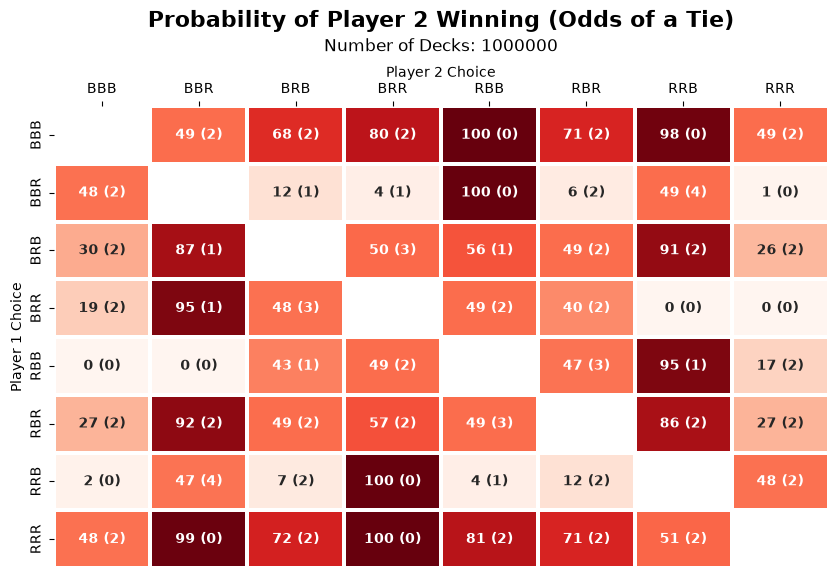

In [78]:
db_path = "points.db"
table_name = "combo_stats"

data = load_data(db_path, table_name)

data2 = process_data(data)

heatmap_data, label_data = create_heatmap_data(data2)

plot_heatmap(
    heatmap_data,
    label_data
)